# Task 1

## Task 1.1

### a. Librerías
Las dependencias están en `requirements.txt`. Para instalarlas (en un entorno virtual):

```bash
python -m venv .venv
.venv\Scripts\activate          # Windows  (Linux/Mac: source .venv/bin/activate)
pip install -r requirements.txt
```

In [1]:
import io
import os
import re
import time
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import requests
import shapely
from shapely.geometry import Point, box
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import rasterize
from rasterio.io import MemoryFile
import pyproj
from scipy.spatial import cKDTree
from matplotlib_scalebar.scalebar import ScaleBar

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 160)

# Verificación de versiones solicitada en el enunciado
print("geopandas :", gpd.__version__)
print("shapely   :", shapely.__version__)
print("pandas    :", pd.__version__)
print("numpy     :", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("requests  :", requests.__version__)
print("rasterio  :", rasterio.__version__)
print("pyproj    :", pyproj.__version__)

geopandas : 1.2.0
shapely   : 2.1.2
pandas    : 3.0.6
numpy     : 2.5.3
matplotlib: 3.11.2
requests  : 2.34.2
rasterio  : 1.5.2
pyproj    : 3.8.0


In [ ]:
ISO3 = "GTM"
COUNTRY = "Guatemala"
CRS_GEO = "EPSG:4326"     # WGS84 geográfico (grados)
CRS_PROJ = "EPSG:32615"   # WGS84 / UTM zona 15N (metros) -> justificación en Task 1.2a
WP_YEAR = 2026            # año más reciente de WorldPop que no es posterior a la fecha de análisis (ver 1.1d)
RADII_KM = [5, 10, 20]    # radios de buffer de Task 1.3
SPEED_KMH = 40            # velocidad promedio por carretera (Task 2.1b)

DATA = Path("data")
DATA.mkdir(exist_ok=True)
HEADERS = {"User-Agent": "CC2017-lab5-modsim/1.0 (uso academico)"}

# Paleta (categórica en orden fijo; diverging azul<->rojo con gris neutro)
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NEUTRAL = "#f0efec"


def download(url, dest, params=None, timeout=300):
    """Descarga `url` a `dest` una sola vez (caché local). Garantiza reproducibilidad sin pasos manuales."""
    dest = Path(dest)
    if dest.exists() and dest.stat().st_size > 0:
        print(f"[caché]    {dest.name}")
        return dest
    print(f"[descarga] {url}")
    r = requests.get(url, params=params, headers=HEADERS, timeout=timeout)
    r.raise_for_status()
    dest.write_bytes(r.content)
    return dest


def pretty(name):
    """GADM 4.1 guarda los nombres sin espacios ('SanMiguelPanán'); se reinsertan para los mapas y tablas."""
    s = re.sub(r"(?<=[a-záéíóúñü])(?=[A-ZÁÉÍÓÚÑ])", " ", str(name))
    s = re.sub(r"([a-záéíóúñ])(de|del)(las|los|la)?(?= [A-ZÁÉÍÓÚÑ])",
               lambda m: f"{m[1]} {m[2]}" + (f" {m[3]}" if m[3] else ""), s)
    return s


def add_north_and_scale(ax, loc="lower left"):
    """Escala gráfica (las coordenadas están en metros) y flecha de norte."""
    ax.add_artist(ScaleBar(1, units="m", location=loc, box_alpha=0.8, length_fraction=0.25))
    ax.annotate("N", xy=(0.95, 0.95), xytext=(0.95, 0.84), xycoords="axes fraction",
                ha="center", va="center", fontsize=14, fontweight="bold",
                arrowprops=dict(facecolor="black", width=4, headwidth=12))

### b. Polígonos administrativos (GADM 4.1)

In [3]:
GADM_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_{iso}_{lvl}.json.zip"


def load_gadm(level):
    zpath = download(GADM_URL.format(iso=ISO3, lvl=level), DATA / f"gadm41_{ISO3}_{level}.json.zip")
    with zipfile.ZipFile(zpath) as zf:
        name = zf.namelist()[0]
        zf.extract(name, DATA)
    return gpd.read_file(DATA / name)


gadm1 = load_gadm(1)
gadm2_raw = load_gadm(2)
gadm1["NAME_1"] = gadm1["NAME_1"].map(pretty)
gadm2_raw["NAME_1"] = gadm2_raw["NAME_1"].map(pretty)
gadm2_raw["NAME_2"] = gadm2_raw["NAME_2"].map(pretty)

# Verificación del CRS: debe ser WGS84 (EPSG:4326)
for lbl, g in [("Nivel 1", gadm1), ("Nivel 2", gadm2_raw)]:
    print(f"{lbl}: {len(g):>3} polígonos | CRS = {g.crs} | ¿WGS84? {g.crs.to_epsg() == 4326}")
    assert g.crs.to_epsg() == 4326

print("\nTipos en nivel 2:", gadm2_raw["TYPE_2"].value_counts().to_dict())

[caché]    gadm41_GTM_1.json.zip
[caché]    gadm41_GTM_2.json.zip
Nivel 1:  22 polígonos | CRS = EPSG:4326 | ¿WGS84? True
Nivel 2: 354 polígonos | CRS = EPSG:4326 | ¿WGS84? True

Tipos en nivel 2: {'Municipio': 352, 'Waterbody': 2}


GADM incluye 2 polígonos de tipo `Waterbody` en el nivel 2 (Lago de Izabal y Lago de Atitlán). No son unidades
administrativas habitadas, así que se separan: los municipios de análisis son los 352 de tipo `Municipio`
(el municipio de Guatemala aparece dividido en sus zonas — `ZONA1`, `ZONA2`, … — en GADM; se conservan así).

In [4]:
water_gadm = gadm2_raw[gadm2_raw["TYPE_2"] == "Waterbody"].copy()
gadm2 = gadm2_raw[gadm2_raw["TYPE_2"] != "Waterbody"].reset_index(drop=True)
gadm2["mun"] = gadm2["NAME_2"] + " (" + gadm2["NAME_1"] + ")"   # etiqueta única
print("Municipios de análisis:", len(gadm2))
gadm1[["GID_1", "NAME_1", "TYPE_1", "geometry"]].head()

Municipios de análisis: 352


,GID_1,NAME_1,TYPE_1,geometry
0,GTM.1_1,Alta Verapaz,Departamento,"MULTIPOLYGON (((-89.6042 15.5026, -89.6148 15...."
1,GTM.2_1,Baja Verapaz,Departamento,"MULTIPOLYGON (((-90.4329 14.9088, -90.436 14.8..."
2,GTM.3_1,Chimaltenango,Departamento,"MULTIPOLYGON (((-90.8891 14.456, -90.8912 14.4..."
3,GTM.4_1,Chiquimula,Departamento,"MULTIPOLYGON (((-89.353 14.4195, -89.361 14.41..."
4,GTM.5_1,El Progreso,Departamento,"MULTIPOLYGON (((-90.2106 14.6863, -90.2384 14...."


### c. Instalaciones de salud (Global Healthsites Mapping Project)

In [5]:
HS_URL = "https://healthsites.io/api/v3/facilities/"
OVERPASS_URL = "https://overpass-api.de/api/interpreter"
MAIN_TYPES = ["hospital", "clinic", "doctors", "pharmacy", "dentist"]
TYPE_ES = {"hospital": "hospital", "clinic": "clínica", "doctors": "consultorio médico",
           "pharmacy": "farmacia", "dentist": "dentista", "other": "otro"}


def get_api_key():
    key = os.environ.get("HEALTHSITES_API_KEY")
    if not key and Path("healthsites_api_key.txt").exists():
        key = Path("healthsites_api_key.txt").read_text().strip()
    return key or None


def classify(amenity, healthcare):
    """Tipo de instalación según las etiquetas OSM que usa healthsites (amenity / healthcare)."""
    for v in (amenity, healthcare):
        v = v.lower() if isinstance(v, str) else ""
        if v == "doctor":
            v = "doctors"
        if v in MAIN_TYPES:
            return v
    return "other"


def fetch_healthsites(api_key, max_pages=500):
    rows, page = [], 1
    while page <= max_pages:
        r = requests.get(HS_URL, headers=HEADERS, timeout=120,
                         params={"api-key": api_key, "page": page, "country": COUNTRY,
                                 "output": "geojson", "flat-properties": "true"})
        if r.status_code in (400, 404):      # fin de la paginación
            break
        r.raise_for_status()
        data = r.json()
        feats = data.get("features", []) if isinstance(data, dict) else data
        if not feats:
            break
        for f in feats:
            props = dict(f.get("properties") or {})
            props.update(props.pop("attributes", None) or {})
            geom = f.get("geometry") or f.get("centroid")
            if not geom:
                continue
            lon, lat = geom["coordinates"][:2]
            rows.append({"osm_type": props.get("osm_type"), "osm_id": props.get("osm_id"),
                         "name": props.get("name"), "amenity": props.get("amenity"),
                         "healthcare": props.get("healthcare"), "lon": lon, "lat": lat})
        page += 1
        time.sleep(0.3)
    return pd.DataFrame(rows)


def fetch_overpass():
    """Respaldo: mismas etiquetas que healthsites.io (amenity=hospital|clinic|doctors|pharmacy|dentist, healthcare=*)."""
    q = f"""[out:json][timeout:170];
    area["ISO3166-1"="GT"][admin_level=2]->.a;
    (nwr["amenity"~"^(hospital|clinic|doctors|pharmacy|dentist)$"](area.a);
     nwr["healthcare"](area.a););
    out center tags;"""
    r = requests.post(OVERPASS_URL, data={"data": q}, headers=HEADERS, timeout=200)
    r.raise_for_status()
    rows = []
    for e in r.json()["elements"]:
        c = e if e["type"] == "node" else e.get("center")
        if not c:
            continue
        t = e.get("tags", {})
        rows.append({"osm_type": e["type"], "osm_id": e["id"], "name": t.get("name"),
                     "amenity": t.get("amenity"), "healthcare": t.get("healthcare"),
                     "lon": c["lon"], "lat": c["lat"]})
    return pd.DataFrame(rows)


fac_cache = DATA / "health_facilities_raw.csv"
if fac_cache.exists():
    fac_df = pd.read_csv(fac_cache)
    print(f"[caché]    {fac_cache.name}  (fuente: {fac_df['source'].iloc[0]})")
else:
    key = get_api_key()
    fac_df = pd.DataFrame()
    if key:
        print("Descargando desde healthsites.io API v3 ...")
        fac_df = fetch_healthsites(key).assign(source="healthsites.io API v3")
    if fac_df.empty:
        print("Sin llave de healthsites.io (o respuesta vacía) -> respaldo OpenStreetMap / Overpass API")
        fac_df = fetch_overpass().assign(source="OpenStreetMap (Overpass API)")
    fac_df.to_csv(fac_cache, index=False)

fac_df = fac_df.drop_duplicates(subset=["osm_type", "osm_id"])
fac_all = gpd.GeoDataFrame(fac_df, geometry=gpd.points_from_xy(fac_df.lon, fac_df.lat), crs=CRS_GEO)
fac_all["tipo"] = [classify(a, h) for a, h in zip(fac_all.amenity, fac_all.healthcare)]
print("Registros descargados:", len(fac_all))

[caché]    health_facilities_raw.csv  (fuente: OpenStreetMap (Overpass API))
Registros descargados: 2058


**Filtro espacial:** se conservan solo las instalaciones que intersectan algún polígono del nivel 1 (`sjoin` con
predicado `intersects`); así se eliminan registros fuera del país o con coordenadas erróneas.

In [6]:
fac = gpd.sjoin(fac_all, gadm1[["NAME_1", "geometry"]], how="inner", predicate="intersects")
fac = fac.drop(columns="index_right").drop_duplicates(subset=["osm_type", "osm_id"]).reset_index(drop=True)
print(f"Instalaciones dentro de Guatemala: {len(fac)}  (descartadas: {len(fac_all) - len(fac)})")

tipos = (fac["tipo"].value_counts().rename("n").to_frame()
         .assign(tipo_es=lambda d: d.index.map(TYPE_ES), pct=lambda d: 100 * d.n / d.n.sum()))
print("\nDetalle de la categoría 'other' (etiqueta healthcare):",
      fac.loc[fac.tipo == "other", "healthcare"].value_counts().to_dict())
tipos

Instalaciones dentro de Guatemala: 2058  (descartadas: 0)

Detalle de la categoría 'other' (etiqueta healthcare): {'laboratory': 29, 'yes': 16, 'centre': 4, 'alternative': 3, 'physiotherapist': 3, 'psychotherapist': 2, 'rehabilitation': 2, 'optometrist': 2, 'hospice': 2, 'podiatrist': 1, 'blood_donation': 1, 'birthing_centre': 1}


,n,tipo_es,pct
tipo,,,
pharmacy,1048,farmacia,50.92
clinic,352,clínica,17.10
hospital,298,hospital,14.48
dentist,184,dentista,8.94
doctors,110,consultorio médico,5.34
other,66,otro,3.21


Se usan los cinco tipos asistenciales que reconoce healthsites
(hospital, clínica, consultorio, farmacia, dentista). La categoría `other` (laboratorios, ópticas, fisioterapia,
medicina alternativa…) no ofrece atención primaria y se excluye del modelo para no inflar la cobertura.

In [7]:
fac = fac[fac["tipo"].isin(MAIN_TYPES)].reset_index(drop=True)
print("Instalaciones en el modelo:", len(fac))

Instalaciones en el modelo: 1992


### d. Ráster de población (WorldPop)

In [8]:
cat = requests.get("https://hub.worldpop.org/rest/data/pop/G2_CN_POP_R25A_1km",
                   params={"iso3": ISO3}, headers=HEADERS, timeout=60).json()["data"]
wp_files = {int(d["popyear"]): d["files"][0] for d in cat}
print("Años disponibles:", sorted(wp_files))
assert WP_YEAR in wp_files
WP_URL = wp_files[WP_YEAR]
wp_path = download(WP_URL, DATA / Path(WP_URL).name)

with rasterio.open(wp_path) as src:
    pop_geo = src.read(1, masked=True)
    wp_meta = src.meta.copy()
    wp_crs, wp_transform, wp_res, wp_bounds = src.crs, src.transform, src.res, src.bounds

lat_c = (wp_bounds.top + wp_bounds.bottom) / 2
res_x_m = wp_res[0] * 111_320 * np.cos(np.radians(lat_c))   # 1° de longitud = 111.32 km · cos(φ)
res_y_m = wp_res[1] * 110_574                                # 1° de latitud ≈ 110.574 km

# máximo: el ráster guarda personas por píxel -> densidad = personas / área del píxel (km²)
r_max, c_max = np.unravel_index(np.ma.argmax(pop_geo), pop_geo.shape)
lat_max = wp_transform.f + (r_max + 0.5) * wp_transform.e
px_area_max = (wp_res[0] * 111_320 * np.cos(np.radians(lat_max))) * res_y_m / 1e6

print(f"\nArchivo                : {wp_path.name}")
print(f"Sistema de coordenadas : {wp_crs}")
print(f"Resolución             : {wp_res[0]:.7f}° × {wp_res[1]:.7f}°  ≈ {res_x_m:,.0f} m × {res_y_m:,.0f} m (a φ={lat_c:.1f}°)")
print(f"Filas × columnas       : {wp_meta['height']} × {wp_meta['width']}")
print(f"Valor NoData           : {wp_meta['nodata']}")
print(f"Población total        : {pop_geo.sum():,.0f} habitantes")
print(f"Máximo por píxel       : {pop_geo.max():,.0f} personas  -> densidad máx ≈ {pop_geo.max() / px_area_max:,.0f} hab/km²")

Años disponibles: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030]
[caché]    gtm_pop_2026_CN_1km_R2025A_UA_v1.tif

Archivo                : gtm_pop_2026_CN_1km_R2025A_UA_v1.tif
Sistema de coordenadas : EPSG:4326
Resolución             : 0.0083333° × 0.0083333°  ≈ 893 m × 921 m (a φ=15.8°)
Filas × columnas       : 489 × 480
Valor NoData           : -99999.0
Población total        : 18,828,240 habitantes
Máximo por píxel       : 14,653 personas  -> densidad máx ≈ 17,721 hab/km²


## Task 1.2

### a. Reproyección y justificación del CRS

**CRS elegido: EPSG:32615 — WGS 84 / UTM zona 15N.**

In [9]:
xs_geo = wp_bounds.left + (np.arange(pop_geo.shape[1]) + 0.5) * wp_res[0]
ys_geo = wp_bounds.top - (np.arange(pop_geo.shape[0]) + 0.5) * wp_res[1]
LON, LAT = np.meshgrid(xs_geo, ys_geo)
popmask = (~pop_geo.mask) & (pop_geo.filled(0) > 0)
lon_p, lat_p, w_p = LON[popmask], LAT[popmask], pop_geo.filled(0)[popmask]

rows = []
for epsg in (32615, 32616):
    k = pyproj.Proj(f"EPSG:{epsg}").get_factors(lon_p, lat_p).meridional_scale
    err = np.abs(k - 1) * 100
    rows.append({"CRS": f"EPSG:{epsg}", "error escala máx (%)": err.max(),
                 "error escala medio ponderado por población (%)": np.average(err, weights=w_p)})
pd.DataFrame(rows).set_index("CRS")

,error escala máx (%),error escala medio ponderado por población (%)
CRS,,
EPSG:32615,0.28,0.05
EPSG:32616,0.35,0.17


El cálculo confirma la elección: con **EPSG:32615** el error de escala máximo es ≈ 0.28 % (extremo oriental, Izabal)
y el error **ponderado por población** es ≈ 0.05 %, tres veces menor que con la zona 16N (≈ 0.17 %). Para un buffer
de 10 km eso es un error de ~5 m para el habitante típico, irrelevante frente a la resolución de 1 km del ráster.

In [10]:
gadm1_p = gadm1.to_crs(CRS_PROJ)
gadm2_p = gadm2.to_crs(CRS_PROJ)
water_p = water_gadm.to_crs(CRS_PROJ)
fac_p = fac.to_crs(CRS_PROJ)
country_p = shapely.union_all(gadm1_p.geometry.values)

# --- Reproyección del ráster a UTM 15N con remuestreo 'sum' (conserva el total de personas) ---
pop_src = pop_geo.filled(0).astype("float32")
dst_transform, W, H = calculate_default_transform(wp_crs, CRS_PROJ, wp_meta["width"], wp_meta["height"],
                                                  *wp_bounds, resolution=1000)
pop_utm = np.zeros((H, W), dtype="float32")
reproject(pop_src, pop_utm, src_transform=wp_transform, src_crs=wp_crs, src_nodata=None,
          dst_transform=dst_transform, dst_crs=CRS_PROJ, dst_nodata=None, resampling=Resampling.sum)
pop_utm[pop_utm < 0] = 0
utm_profile = dict(driver="GTiff", height=H, width=W, count=1, dtype="float32",
                   crs=CRS_PROJ, transform=dst_transform, nodata=0)

print(f"Ráster UTM: {H} × {W} píxeles de 1000 m")
print(f"Población original (WGS84) : {pop_src.sum():,.0f}")
print(f"Población reproyectada     : {pop_utm.sum():,.0f}   (diferencia {100 * (pop_utm.sum() / pop_src.sum() - 1):+.2f} %)")
for name, g in [("gadm1", gadm1_p), ("gadm2", gadm2_p), ("instalaciones", fac_p)]:
    print(f"{name:<14} -> {g.crs}")

Ráster UTM: 458 × 435 píxeles de 1000 m
Población original (WGS84) : 18,828,240
Población reproyectada     : 18,828,238   (diferencia -0.00 %)
gadm1          -> EPSG:32615
gadm2          -> EPSG:32615
instalaciones  -> EPSG:32615


**Estructuras auxiliares (se reutilizan en todo el notebook).** Se trabaja con los centros de los píxeles UTM:

* `zone2`/`zone1`: rasterización de municipios/departamentos sobre la grilla del ráster (cada píxel pertenece a
  la división que contiene su centro — misma regla que `rasterio.mask` con `all_touched=False`). Con esto,
  la población de una división es $P_k = \sum_{i \in k} P_i$ (estadística zonal).
* `d_pix`: distancia de cada píxel a la instalación más cercana, $d_i = \min_j \lVert x_i - s_j \rVert$, calculada con
  un árbol k-d. Como $x_i \in C_r \iff d_i \le r$, esto permite evaluar la cobertura para cualquier radio sin
  reconstruir los buffers.

In [11]:
zone2 = rasterize(((g, i) for i, g in enumerate(gadm2_p.geometry)), out_shape=(H, W),
                  transform=dst_transform, fill=-1, dtype="int32")
zone1 = rasterize(((g, i) for i, g in enumerate(gadm1_p.geometry)), out_shape=(H, W),
                  transform=dst_transform, fill=-1, dtype="int32")
# Municipios más pequeños que un píxel (p. ej. ZONA4, 0.9 km²) no contienen ningún centro de píxel:
# se les asigna el píxel que contiene su punto representativo para que no queden con población 0.
for i in sorted(set(range(len(gadm2_p))) - set(np.unique(zone2))):
    pt = gadm2_p.geometry.iloc[i].representative_point()
    r_, c_ = rasterio.transform.rowcol(dst_transform, pt.x, pt.y)
    print(f"Municipio sin centro de píxel -> píxel ({r_}, {c_}): {gadm2_p['mun'].iloc[i]}")
    zone2[r_, c_] = i
cols, rows_ = np.meshgrid(np.arange(W), np.arange(H))
X = dst_transform.c + (cols + 0.5) * dst_transform.a
Y = dst_transform.f + (rows_ + 0.5) * dst_transform.e

inside = zone2 >= 0                                    # píxeles dentro de algún municipio
px_x, px_y = X[inside], Y[inside]
px_pop, px_z2, px_z1 = pop_utm[inside].astype(float), zone2[inside], zone1[inside]
P_TOTAL = px_pop.sum()

fac_xy = np.column_stack([fac_p.geometry.x, fac_p.geometry.y])
fac_tree = cKDTree(fac_xy)
d_pix, nn_pix = fac_tree.query(np.column_stack([px_x, px_y]))   # metros

print(f"Población asignada a municipios: {P_TOTAL:,.0f} ({100 * P_TOTAL / pop_utm.sum():.2f} % del ráster;"
      " el resto cae en píxeles de borde/lagos)")

Municipio sin centro de píxel -> píxel (358, 186): ZONA4 (Guatemala)
Población asignada a municipios: 18,711,833 (99.38 % del ráster; el resto cae en píxeles de borde/lagos)


### b. Mapa base de tres capas

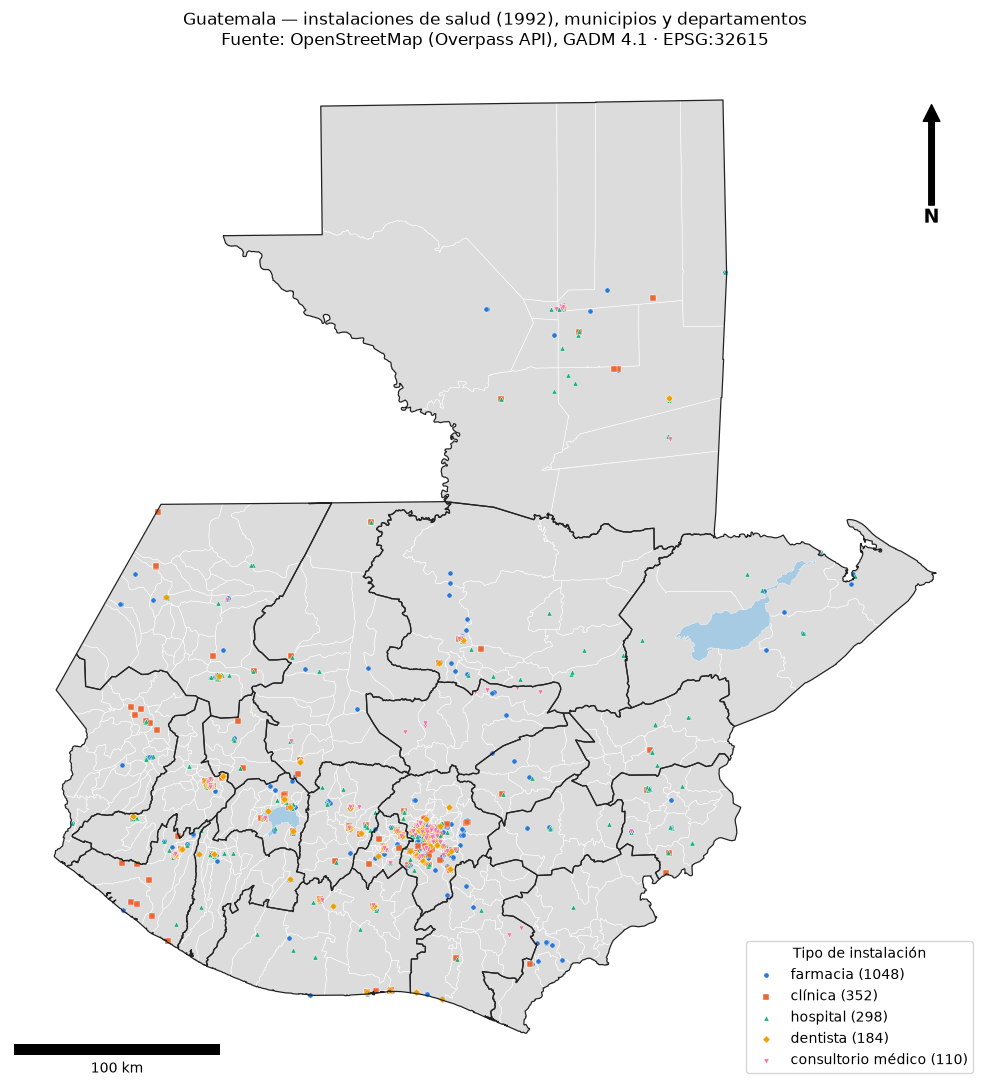

In [12]:
type_style = {  # color (orden categórico fijo) + forma de marcador (codificación secundaria)
    "pharmacy": (CAT[0], "o"), "clinic": (CAT[1], "s"), "hospital": (CAT[2], "^"),
    "dentist": (CAT[3], "D"), "doctors": (CAT[4], "v")}

fig, ax = plt.subplots(figsize=(11, 11))
gadm2_p.plot(ax=ax, color="#dcdcdc", edgecolor="white", linewidth=0.4)
water_p.plot(ax=ax, color="#a6cbe3", edgecolor="none")
for t, (col, mk) in type_style.items():
    sub = fac_p[fac_p.tipo == t]
    sub.plot(ax=ax, color=col, marker=mk, markersize=14, edgecolor="white", linewidth=0.3,
             label=f"{TYPE_ES[t]} ({len(sub)})", zorder=3)
gadm1_p.boundary.plot(ax=ax, color="#222222", linewidth=0.9, zorder=4)
ax.legend(title="Tipo de instalación", loc="lower right", frameon=True)
add_north_and_scale(ax)
ax.set_title(f"Guatemala — instalaciones de salud ({len(fac_p)}), municipios y departamentos\n"
             f"Fuente: {fac_df['source'].iloc[0]}, GADM 4.1 · {CRS_PROJ}", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### c. Estadísticas por departamento (nivel 1)

* **Población** $P_k$: suma de los píxeles WorldPop cuyo centro cae en el departamento (estadística zonal).
* **Instalaciones por 100,000 hab.:** $\rho_k = 10^5 \cdot n_k / P_k$.
* **Distancia promedio al vecino más cercano:** $\bar d^{NN}_k = \frac{1}{n_k}\sum_{j\in k} \min_{l \ne j} \lVert s_j - s_l\rVert$,
  calculada entre instalaciones del mismo departamento (árbol k-d, $k=2$ porque el primer vecino es el propio punto).

In [13]:
def mean_nn_km(pts):
    if len(pts) < 2:
        return np.nan
    d, _ = cKDTree(pts).query(pts, k=2)
    return d[:, 1].mean() / 1000


dept = gadm1_p[["NAME_1", "geometry"]].copy()
dept["instalaciones"] = dept["NAME_1"].map(fac_p["NAME_1"].value_counts()).fillna(0).astype(int)
dept["area_km2"] = dept.area / 1e6
dept["poblacion"] = np.bincount(px_z1[px_z1 >= 0], weights=px_pop[px_z1 >= 0], minlength=len(dept))
dept["inst_por_100k"] = 1e5 * dept["instalaciones"] / dept["poblacion"]
dept["dist_nn_prom_km"] = [mean_nn_km(fac_xy[fac_p["NAME_1"].values == n]) for n in dept["NAME_1"]]
dept_tbl = dept.drop(columns="geometry").sort_values("inst_por_100k").reset_index(drop=True)
dept_tbl.index += 1
dept_tbl

,NAME_1,instalaciones,area_km2,poblacion,inst_por_100k,dist_nn_prom_km
1,Totonicapán,7,"1,077.25","509,248.92",1.37,1.87
2,San Marcos,27,"3,541.66","1,277,661.63",2.11,1.30
3,El Progreso,5,"1,687.94","210,003.81",2.38,3.01
4,Jutiapa,15,"3,351.32","610,731.53",2.46,2.77
5,Santa Rosa,13,"3,023.90","482,857.37",2.69,3.08
6,Baja Verapaz,11,"2,821.31","344,362.91",3.19,7.16
7,Zacapa,10,"2,727.04","299,803.59",3.34,1.01
8,Jalapa,15,"1,972.96","436,235.54",3.44,2.01
9,Quiché,42,"7,231.63","1,203,121.11",3.49,1.48
10,Alta Verapaz,53,"10,061.75","1,456,242.33",3.64,2.49


In [14]:
low3 = dept_tbl.head(3)
print("Departamentos con MENOR densidad de cobertura (instalaciones por 100,000 hab.):")
for _, r in low3.iterrows():
    print(f"  - {r.NAME_1:<15} {r.inst_por_100k:5.2f} inst/100k hab | {r.instalaciones:>3} inst. para "
          f"{r.poblacion:,.0f} hab. | {r.area_km2:,.0f} km² | vecino más cercano prom. {r.dist_nn_prom_km:.1f} km")

Departamentos con MENOR densidad de cobertura (instalaciones por 100,000 hab.):
  - Totonicapán      1.37 inst/100k hab |   7 inst. para 509,249 hab. | 1,077 km² | vecino más cercano prom. 1.9 km
  - San Marcos       2.11 inst/100k hab |  27 inst. para 1,277,662 hab. | 3,542 km² | vecino más cercano prom. 1.3 km
  - El Progreso      2.38 inst/100k hab |   5 inst. para 210,004 hab. | 1,688 km² | vecino más cercano prom. 3.0 km
